In [6]:
import pandas as pd
import json
from pathlib import Path


district_nums = [(8,5), (10,4), (16,5), (20,4), (40,1), (80,1)]
district_mode = ["cambridge", "slate_pl", "slate_bt"]
parties = ["D", "R"]
party_focal = parties[0]
races = ["H", "O"]
race_focal = races[0]
plans = ["000", "200", "400", "600", "800"]
num_profiles_per_district = 100 ### CHANGE

# Might need to run vk_settings_generator again

## Extract results for race

In [ ]:
def avg_prop(dist_res, num_profiles, seats, focal):
    all_entries = [item for unit in dist_res for item in unit]
    # Count how many belong in focal group
    count = sum(1 for item in all_entries if item.startswith(focal))
        
    # Divide by number of profile reps
    prop = count / (num_profiles*seats)
    return(prop)


In [ ]:
rows = []

# For each district division x seats per district
for (dn, eln) in district_nums:

    # For each mode
    for dm in district_mode:
        results_file=Path(f"./vk_ca_election_model_results_racial/{dm}/ca_{dn}_districts_{eln}_winners_for_voter_model_{dm}.json")

        # For each results file, first divide into results from dn different plans
        # Within each plan, each district was repeated by num_profiles_per_district=100
        # Currently assuming order of result file is (plan1,district1)*100, (plan1, district2)*100, ...(plan2, district1)*100

        with open(results_file, "r") as f:
            data = json.load(f)
            plan_data_len = len(data) // len(plans)

            # First split each result file into results from eachp plan
            results_by_plan = [data[i*plan_data_len:(i+1)*plan_data_len] for i in range(len(plans))]

            # For each grouped results by plan
            for pn in range(len(results_by_plan)):
                res_plan = results_by_plan[pn]

                # Split into grouped results by district. Each district should have reps of num_profiles_per_district=100
                results_by_district = [res_plan[i:i+num_profiles_per_district] for i in range(0, len(res_plan), num_profiles_per_district)]

                # For each district
                for dist_id in range(len(results_by_district)):
                    res_dist = results_by_district[dist_id]

                    # Calculate average proportion across vk election results
                    pr = avg_prop(res_dist, num_profiles_per_district, eln, race_focal)

                    # Add census demographic info from settings file
                    settings_folder = Path(f"./vk_run_settings_racial_turnout/{dn}")
                    settings_filename = f"ca_{dn}_vk_sample_settings_district_plan_{plans[pn]}_district_{dist_id:02d}.json"
                    settings_filepath = settings_folder / settings_filename

                    with open(settings_filepath, "r") as g:
                        settings_data = json.load(g)
                        total_hvap = settings_data.get("total_hvap", None)
                        total_vap = settings_data.get("total_vap", None)                        
                        rows.append({"plan": plans[pn],
                                    "total_district_num": dn,
                                    "total_elected": eln,
                                    "dist_num": dist_id,
                                    "mode": dm,
                                    "H_vk_avg_prop": pr,
                                    "H_prop_census": total_hvap/total_vap})

df = pd.DataFrame(rows)
df.head()

In [ ]:
df.to_csv("Racial_results.csv", index=False) 


## Extract results for partisanship

In [ ]:
partisan_rows = []

# For each district division x seats per district
for (dn, eln) in district_nums:

    # For each mode
    for dm in district_mode:
        results_file=Path(f"./vk_ca_election_model_results_partisan_debug/{dm}/ca_{dn}_districts_{eln}_partisan_winners_for_voter_model_{dm}.json")

        # For each results file, first divide into results from dn different plans
        # Within each plan, each district was repeated by num_profiles_per_district=100
        # Currently assuming order of result file is (plan1,district1)*100, (plan1, district2)*100, ...(plan2, district1)*100

        with open(results_file, "r") as f:
            raw_data = json.load(f)
            data = raw_data#[-dn*eln*num_profiles_per_district:]
            plan_data_len = len(data) // len(plans)

            # First split each result file into results from each plan
            results_by_plan = [data[i*plan_data_len:(i+1)*plan_data_len] for i in range(len(plans))]

            # For each grouped results by plan
            for pn in range(len(results_by_plan)):
                res_plan = results_by_plan[pn]

                # Split into grouped results by district. Each district should have reps of num_profiles_per_district=100
                results_by_district = [res_plan[i:i+num_profiles_per_district] for i in range(0, len(res_plan), num_profiles_per_district)]

                # For each district
                for dist_id in range(len(results_by_district)):
                    res_dist = results_by_district[dist_id]

                    # Calculate average proportion across vk election results
                    pr = avg_prop(res_dist, num_profiles_per_district, eln, party_focal)

                    # Add census demographic info from settings file
                    settings_folder = Path(f"./vk_run_settings_partisan/{dn}")
                    settings_filename = f"ca_{dn}_vk_sample_settings_partisan_district_plan_{plans[pn]}_district_{dist_id:02d}.json"
                    settings_filepath = settings_folder / settings_filename

                    with open(settings_filepath, "r") as g:
                        settings_data = json.load(g)
                        bloc_pr = settings_data.get("bloc_proportions", None)

                        partisan_rows.append({"plan": plans[pn],
                                    "total_district_num": dn,
                                    "total_elected": eln,
                                    "dist_num": dist_id,
                                    "mode": dm,
                                    "Dem_vk_avg_prop": pr,
                                    "Dem_prop_census": bloc_pr["D"]/(bloc_pr["D"]+bloc_pr["R"])})

partisan_df = pd.DataFrame(partisan_rows)
partisan_df.head()

In [ ]:
partisan_df.to_csv("Partisan_results.csv", index=False) 

## Histograms of Hispanic seat count for each district x seat configuration

In [7]:
def count_focal_winners(rep_res, focal):
    # Count how many belong in focal group
    all_entries = [item for unit in rep_res for item in unit]
    count = sum(1 for item in all_entries if item.startswith(focal))
    return(count)

In [57]:
rows = []

# For each district division x seats per district
for (dn, eln) in district_nums:

    # For each mode
    for dm in district_mode:
        results_file=Path(f"./vk_ca_election_model_results_racial_turnout/{dm}/ca_{dn}_districts_{eln}_winners_for_voter_model_{dm}.json")

        # For each results file, first divide into results from dn different plans
        # Within each plan, each district was repeated by num_profiles_per_district=100
        # Currently assuming order of result file is (plan1,district1)*100, (plan1, district2)*100, ...(plan2, district1)*100

        with open(results_file, "r") as f:
            data = json.load(f)
            plan_data_len = len(data) // len(plans)

            # First split each result file into results from eachp plan
            results_by_plan = [data[i*plan_data_len:(i+1)*plan_data_len] for i in range(len(plans))]

            # For each grouped results by plan
            for pn in range(len(results_by_plan)):
                res_plan = results_by_plan[pn]

                # Split into grouped results by district. Each district should have reps of num_profiles_per_district=100
                results_by_district = [res_plan[i:i+num_profiles_per_district] for i in range(0, len(res_plan), num_profiles_per_district)]
                # For each district
                for dist_id in range(len(results_by_district)):
                    res_dist = results_by_district[dist_id]

                    # For each rep
                    for rep_n in range(len(res_dist)):
                        # Result per rep
                        rep_res = res_dist[rep_n]
                        # Calculate average proportion across vk election results
                        rep_count = count_focal_winners(rep_res, race_focal)
                        
                        # Add census demographic info from settings file
                        settings_folder = Path(f"./vk_run_settings_racial_turnout/{dn}")
                        settings_filename = f"ca_{dn}_vk_sample_settings_district_plan_{plans[pn]}_district_{dist_id:02d}.json"
                        settings_filepath = settings_folder / settings_filename

                        with open(settings_filepath, "r") as g:
                            settings_data = json.load(g)
                            total_hvap = settings_data.get("total_hvap", None)
                            total_vap = settings_data.get("total_vap", None)                        
                            rows.append({"plan": plans[pn],
                                        "total_district_num": dn,
                                        "seats_per_district": eln,
                                        "dist_num": dist_id,
                                        "mode": dm,
                                        "vap": total_vap,
                                        "hvap": total_hvap,
                                        "rep": rep_n,
                                        "H_seats": rep_count})

df_hist = pd.DataFrame(rows)
# df_hist.head()

In [ ]:
# Histograms for seat frequency per config

import matplotlib.pyplot as plt

dist_seats = {8:5, 10:4, 16:5, 20:4, 40:1, 80:1}

for dn, group in df_hist.groupby("total_district_num"):
    plt.figure(figsize=(6,4))
    plt.hist(group["H_seats"], bins=range(group["H_seats"].min(), group["H_seats"].max()+2), 
             align='left', edgecolor='gray', color='skyblue')
    plt.xticks(range(group["H_seats"].min(), group["H_seats"].max()+1))
    plt.xlabel("Seats for Focal Race")
    plt.ylabel("Frequency")
    plt.title(f"Hispanic seats from {dn} district x {dist_seats[dn]} seat plans")
    plt.show()

In [84]:
## Compute HVAP proportion

import pandas as pd
from IPython.display import display, HTML

df_filtered = df_hist[
    (df_hist["plan"] == "000") &
    (df_hist["mode"] == "cambridge") &
    (df_hist["rep"] == 0) &
    (df_hist["total_district_num"] == 8)
]

#display(HTML(f"<div style='height:400px; overflow:auto'>{df_filtered.to_html()}</div>"))

print(sum(df_filtered["hvap"]))
print(sum(df_filtered["vap"]))
hvap = sum(df_filtered["hvap"])
vap = sum(df_filtered["vap"])
hprop = hvap/vap

print(hprop)

turnout = {"H": 0.4, "O": 1}
hprop_turnout = hprop*turnout["H"] / (hprop*turnout["H"] + (1-hprop)*turnout["O"])


## Compute combined support
cs = hprop * 0.75 + (1-hprop) * 0.2
cs_turnout = hprop_turnout * 0.75 + (1-hprop_turnout) * 0.2

print(cs)


10932015.0
30827105.0
0.3546234717791372
0.3950429094785255


## Draw histogram of seat count for each run

In [ ]:
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['font.sans-serif'] = ['Nunito Sans']

agg = (df_hist.groupby(["plan", "total_district_num", "mode", "rep"], as_index=False)
      .agg({"H_seats": "sum"}))


dist_seats = {8:5, 10:4, 16:5, 20:4, 40:1, 80:1}

# colors to try: soft pink, apricot
for dn, group in agg.groupby("total_district_num"): 
    plt.rc('font', size=9)   
    fig, ax = plt.subplots(figsize=(6,4))  # create a figure + axes
    
    ax.hist(
        group["H_seats"],
        bins=range(group["H_seats"].min(), group["H_seats"].max() + 2),
        align='left',
        edgecolor='gray',
        linewidth = 0.5,
        color='xkcd:light periwinkle'
    )

    # Reduce the weight of the spines (plot boundary)
    for spine in ax.spines.values():
        spine.set_linewidth(0.5)

    
    sen_assem = "Senate" if dn*dist_seats[dn] == 40 else "Assembly"
    election = "IRV" if dist_seats[dn]==1 else "STV"
    ylim = 350 if sen_assem == "Senate" else 200


    ax.set_xlim(-1, dn * dist_seats[dn] + 1)
    ax.set_ylim(0, ylim)
    ax.set_xticks(range(0, dn * dist_seats[dn] + 1, 10))
    ax.set_xlabel(f"{sen_assem} Seats")
    ax.set_ylabel("Count")
    ax.set_title(f"{sen_assem} representation for Hispanic-preferred candidates, {dn} x {dist_seats[dn]} {election}")



### ADD VERTICAL LINES
    color_cs = 'xkcd:steel'
    color_hprop = 'xkcd:twilight'

    ## Add vertical line for combined support
    cs_share = cs*dn*dist_seats[dn]
    ax.axvline(
        cs_share, color=color_cs, linestyle=':', linewidth=1,
        label=f"{share}"
    )

    rounded_cs = f"{cs_share:.2f}"
    cs_text_label = f"Combined support\n{rounded_cs}"
    ax.text(
        cs_share + 0.5, # X-position: slightly to the right of the line
        ylim * 0.83, # Y-position: 95% of the way up the plot
        cs_text_label,
        verticalalignment='center',
        horizontalalignment='left',
        fontsize=8,
        color=color_cs
    )
    
    ## Add vertical line for population proprotionate share
    # Add dotted vertical line at hprop * seats
    share = hprop*dn*dist_seats[dn]
    ax.axvline(
        share, color=color_hprop, linestyle=':', linewidth=1,
        label=f"{share}"
    )
    
    rounded_share = f"{share:.2f}"
    text_label = f"Population proportion \n{rounded_share}"

    ax.text(
        share + 0.5, # X-position: slightly to the right of the line
        ylim * 0.93, # Y-position: 95% of the way up the plot
        text_label,
        verticalalignment='center',
        horizontalalignment='left',
        fontsize=8,
        color=color_hprop
    )

    ax.tick_params(axis='both', which='major', labelsize=8)
    plt.savefig(f"figures/hispanic seats {dn} x {dist_seats[dn]}_turn_h0.4_pih0.75_pio0.8_ahh0.25_aho0.75_aoh0.6_aoo0.5.png", dpi=300, bbox_inches='tight') 

## Histogram where each mode is divided

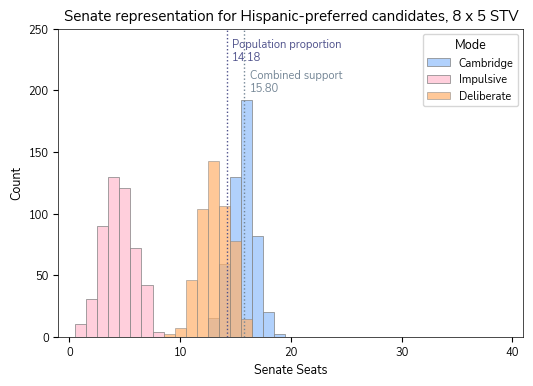

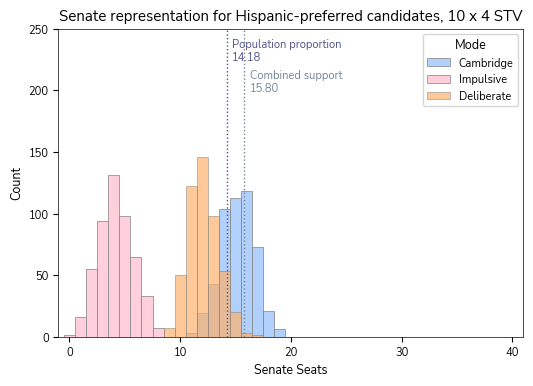

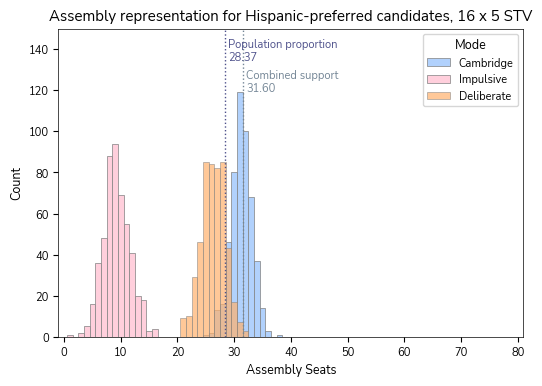

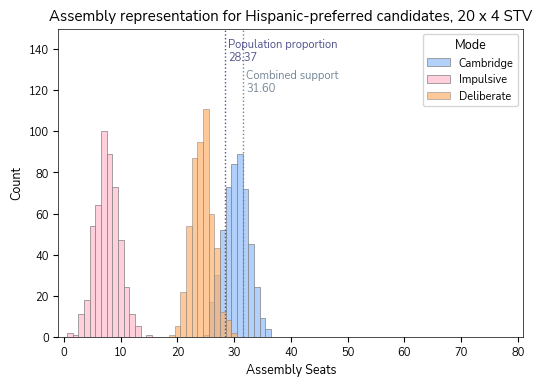

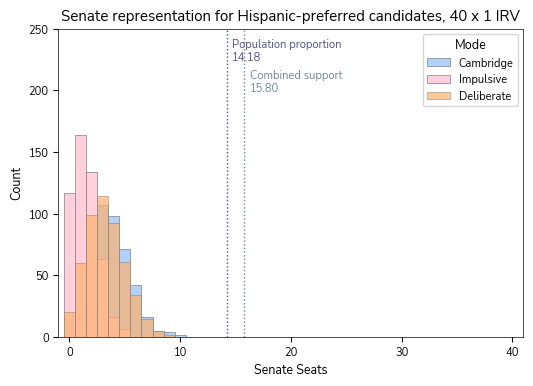

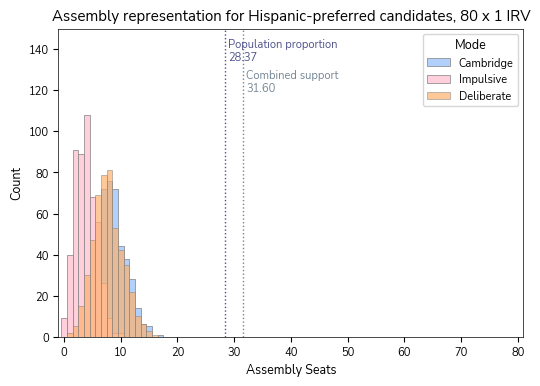

In [149]:
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['font.sans-serif'] = ['Nunito Sans']

agg = (df_hist.groupby(["plan", "total_district_num", "mode", "rep"], as_index=False)
      .agg({"H_seats": "sum"}))

dist_seats = {8:5, 10:4, 16:5, 20:4, 40:1, 80:1}

# Define colors for each mode
mode_colors = {
    "cambridge": "xkcd:powder blue",
    "slate_bt": "xkcd:pale pink",
    "slate_pl": "xkcd:apricot"
}
# Define the mapping for the new legend labels
legend_mapping = {
    "slate_bt": "Impulsive",
    "slate_pl": "Deliberate",
    "cambridge": "Cambridge"
}

for dn, group_dn in agg.groupby("total_district_num"): 
    plt.rc('font', size=9)   
    fig, ax = plt.subplots(figsize=(6,4))  # create a figure + axes

    # Plot histogram for each mode
    for mode, group_mode in group_dn.groupby("mode"):
        alpha_val = 0.7 if mode_colors.get(mode) == "xkcd:apricot" else 1.0
        ax.hist(
            group_mode["H_seats"],
            bins=range(group_mode["H_seats"].min(), group_mode["H_seats"].max() + 2),
            align='left',
            edgecolor='gray',
            linewidth=0.5,
            color=mode_colors.get(mode, "xkcd:light gray"),
            alpha=alpha_val,
            label=mode  # add label for legend
        )

    # Reduce the weight of the spines (plot boundary)
    for spine in ax.spines.values():
        spine.set_linewidth(0.5)

    sen_assem = "Senate" if dn*dist_seats[dn] == 40 else "Assembly"
    election = "IRV" if dist_seats[dn]==1 else "STV"
    ylim = 250 if sen_assem == "Senate" else 150

    # set x-axis limits on the Axes
    ax.set_xlim(-1, dn * dist_seats[dn] + 1)
    ax.set_ylim(0, ylim)
    ax.set_xticks(range(0, dn * dist_seats[dn] + 1, 10))
    ax.set_xlabel(f"{sen_assem} Seats")
    ax.set_ylabel("Count")
    ax.set_title(f"{sen_assem} representation for Hispanic-preferred candidates, {dn} x {dist_seats[dn]} {election}")
    ax.tick_params(axis='both', which='major', labelsize=8)


    # ADD A MODIFIED LEGEND
    # Get handles and labels from the current axes
    handles, labels = ax.get_legend_handles_labels()

    # Filter out vertical line handles and labels from the main histogram legend
    # and map the labels to the new, descriptive names
    new_labels = []
    new_handles = []
    
    for handle, label in zip(handles, labels):
        # Only process labels that are keys in the legend_mapping (i.e., histogram labels)
        if label in legend_mapping:
            new_labels.append(legend_mapping[label])
            new_handles.append(handle)

    # Add legend for modes using the new labels
    ax.legend(new_handles, new_labels, title="Mode", fontsize=8)



    ### ADD VERTICAL LINES
    color_cs = 'xkcd:steel'
    color_hprop = 'xkcd:twilight'

    ## Add vertical line for combined support
    cs_share = cs*dn*dist_seats[dn]
    ax.axvline(
        cs_share, color=color_cs, linestyle=':', linewidth=1,
        label=f"{share}"
    )

    rounded_cs = f"{cs_share:.2f}"
    cs_text_label = f"Combined support\n{rounded_cs}"
    ax.text(
        cs_share + 0.5, # X-position: slightly to the right of the line
        ylim * 0.83, # Y-position: 95% of the way up the plot
        cs_text_label,
        verticalalignment='center',
        horizontalalignment='left',
        fontsize=8,
        color=color_cs
    )
    
    ## Add vertical line for population proprotionate share
    # Add dotted vertical line at hprop * seats
    share = hprop*dn*dist_seats[dn]
    ax.axvline(
        share, color=color_hprop, linestyle=':', linewidth=1,
        label=f"{share}"
    )
    
    rounded_share = f"{share:.2f}"
    text_label = f"Population proportion \n{rounded_share}"

    ax.text(
        share + 0.5, # X-position: slightly to the right of the line
        ylim * 0.93, # Y-position: 95% of the way up the plot
        text_label,
        verticalalignment='center',
        horizontalalignment='left',
        fontsize=8,
        color=color_hprop
    )

    # Save figure
    plt.savefig(f"figures/hispanic_seats_{dn}x{dist_seats[dn]}_bymode_turn_h0.4_pih0.75_pio0.8_ahh0.25_aho0.75_aoh0.6_aoo0.5.png.png", dpi=300, bbox_inches='tight')

In [148]:
import numpy as np

def bubble_plot_integer(ax, data, labels, colors, title, marker =".", size = 1000):
    # create figure
    # fig, ax = plt.subplots() #plt.figure()
    
    x_max = int(max(max(vector) for vector in data))
    bin_min = 0
    bin_max = x_max
    bins = np.arange(bin_min-.5, bin_max+1.5, 1)
    
    for j, vector in enumerate(data):
        x = [i for i in range(x_max+1)] # x=0,...,x_max
        y = [j+1]*len(x) # put each vector at a different height
        
        bin_heights, bin_edges = np.histogram(vector, bins = bins,density=True)
        circle_areas = [size*bin_heights[i] for i in range(x_max+1)]
        ax.scatter(x, y, s=circle_areas, alpha=1, color = colors[j], label = None, edgecolors='black', marker=marker)

    # Add labels and title
    ax.set_xlabel(f'Seats')
    ax.set_xticks([i for i in range(x_max+1)])
    ax.set_yticks([i+1 for i in range(len(data))], labels)
    ax.set_xlim((-2, x_max+2))
    ax.set_ylim((0.5, len(data)+.5))
    ax.set_title(title)
    
    return ax

## Histograms of Partisan seat count for each config

In [152]:
rows = []

# For each district division x seats per district
for (dn, eln) in district_nums:

    # For each mode
    for dm in district_mode:
        results_file=Path(f"./vk_ca_election_model_results_partisan/{dm}/ca_{dn}_districts_{eln}_partisan_winners_for_voter_model_{dm}.json")

        # For each results file, first divide into results from dn different plans
        # Within each plan, each district was repeated by num_profiles_per_district=100
        # Currently assuming order of result file is (plan1,district1)*100, (plan1, district2)*100, ...(plan2, district1)*100

        with open(results_file, "r") as f:
            data = json.load(f)
            plan_data_len = len(data) // len(plans)

            # First split each result file into results from eachp plan
            results_by_plan = [data[i*plan_data_len:(i+1)*plan_data_len] for i in range(len(plans))]

            # For each grouped results by plan
            for pn in range(len(results_by_plan)):
                res_plan = results_by_plan[pn]

                # Split into grouped results by district. Each district should have reps of num_profiles_per_district=100
                results_by_district = [res_plan[i:i+num_profiles_per_district] for i in range(0, len(res_plan), num_profiles_per_district)]
                # For each district
                for dist_id in range(len(results_by_district)):
                    res_dist = results_by_district[dist_id]

                    # For each rep
                    for rep_n in range(len(res_dist)):
                        # Result per rep
                        rep_res = res_dist[rep_n]
                        # Calculate average proportion across vk election results
                        rep_count = count_focal_winners(rep_res, party_focal)
                        
                        # Add census demographic info from settings file
                        settings_folder = Path(f"./vk_run_settings_partisan/{dn}")
                        settings_filename = f"ca_{dn}_vk_sample_settings_partisan_district_plan_{plans[pn]}_district_{dist_id:02d}.json"
                        settings_filepath = settings_folder / settings_filename

                        with open(settings_filepath, "r") as g:
                            settings_data = json.load(g)
                            bloc_pr = settings_data.get("bloc_proportions", None)      
                            bloc_vap = settings_data.get("vap", None)                   
                            rows.append({"plan": plans[pn],
                                        "total_district_num": dn,
                                        "seats_per_district": eln,
                                        "dist_num": dist_id,
                                        "mode": dm,
                                        "Dem_prop_census": bloc_pr["D"]/(bloc_pr["D"]+bloc_pr["R"]),
                                        "vap": bloc_vap,
                                        "rep": rep_n,
                                        "D_seats": rep_count})





df_part = pd.DataFrame(rows)
df_part.head()

,plan,total_district_num,seats_per_district,dist_num,mode,Dem_prop_census,vap,rep,D_seats
0,000,8,5,0,cambridge,0.745985,3689662.0,0,2
1,000,8,5,0,cambridge,0.745985,3689662.0,1,3
2,000,8,5,0,cambridge,0.745985,3689662.0,2,2
3,000,8,5,0,cambridge,0.745985,3689662.0,3,3
4,000,8,5,0,cambridge,0.745985,3689662.0,4,3


In [157]:
## Get democrat proportions

import pandas as pd
from IPython.display import display, HTML
import numpy as np

df_filtered = df_part[
    (df_part["plan"] == "000") &
    (df_part["mode"] == "cambridge") &
    (df_part["rep"] == 0) &
    (df_part["total_district_num"] == 8)
]

display(HTML(f"<div style='height:400px; overflow:auto'>{df_filtered.to_html()}</div>"))

print(sum(df_filtered["vap"]))
vap = sum(df_filtered["vap"])
dprop = np.dot(df_filtered["Dem_prop_census"], df_filtered["vap"])/vap

print(dprop)
# print(hprop)

# turnout = {"H": 0.4, "O": 1}
# hprop_turnout = hprop*turnout["H"] / (hprop*turnout["H"] + (1-hprop)*turnout["O"])


## Compute combined support
cs = dprop * 0.75 + (1-dprop) * 0.2
#cs_turnout = hprop_turnout * 0.75 + (1-hprop_turnout) * 0.2


,plan,total_district_num,seats_per_district,dist_num,mode,Dem_prop_census,vap,rep,D_seats
0,000,8,5,0,cambridge,0.745985,3689662.0,0,2
100,000,8,5,1,cambridge,0.805292,3828234.0,0,3
200,000,8,5,2,cambridge,0.677311,3966479.0,0,3
300,000,8,5,3,cambridge,0.676669,3777006.0,0,3
400,000,8,5,4,cambridge,0.523010,3978981.0,0,3
500,000,8,5,5,cambridge,0.609047,3923027.0,0,3
600,000,8,5,6,cambridge,0.571163,3994207.0,0,3
700,000,8,5,7,cambridge,0.597300,3669509.0,0,3


30827105.0
0.6494641899924751


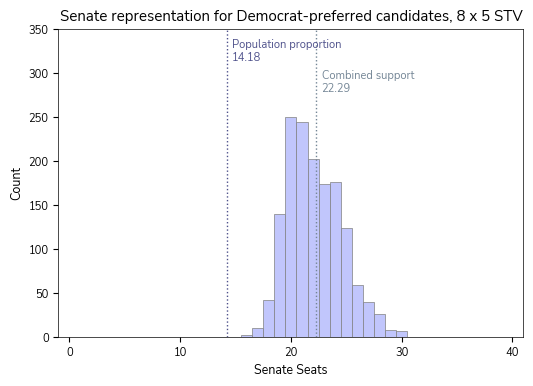

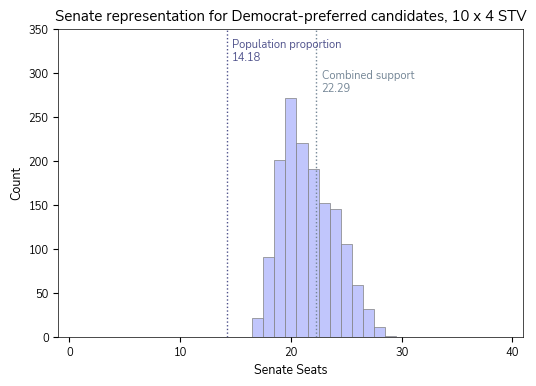

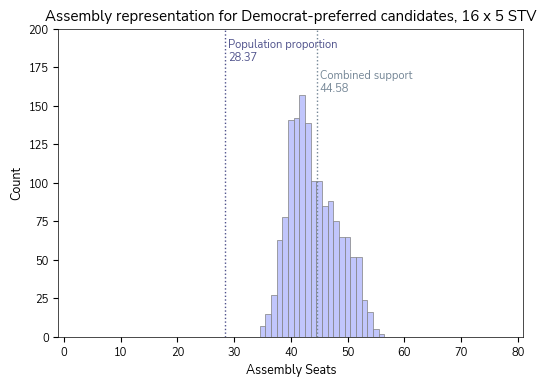

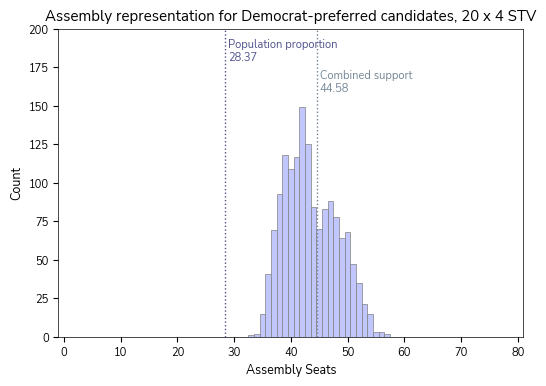

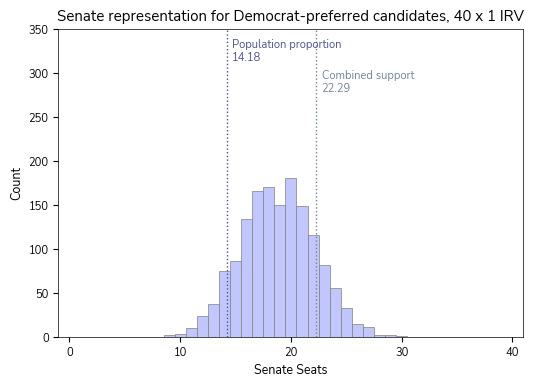

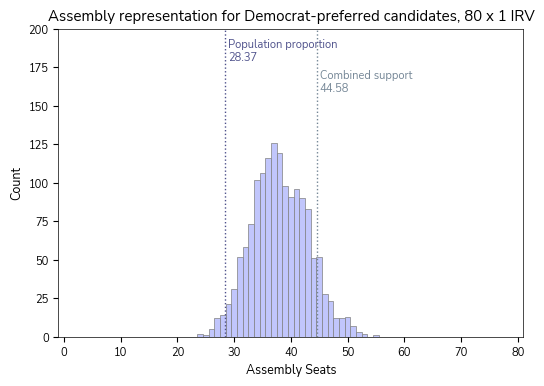

In [ ]:
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['font.sans-serif'] = ['Nunito Sans']

agg = (df_part.groupby(["plan", "total_district_num", "mode", "rep"], as_index=False)
      .agg({"D_seats": "sum"}))


dist_seats = {8:5, 10:4, 16:5, 20:4, 40:1, 80:1}

# colors to try: soft pink, apricot
for dn, group in agg.groupby("total_district_num"): 
    plt.rc('font', size=9)   
    fig, ax = plt.subplots(figsize=(6,4))  # create a figure + axes
    
    ax.hist(
        group["D_seats"],
        bins=range(group["D_seats"].min(), group["D_seats"].max() + 2),
        align='left',
        edgecolor='gray',
        linewidth = 0.5,
        color='xkcd:light periwinkle'
    )

    # Reduce the weight of the spines (plot boundary)
    for spine in ax.spines.values():
        spine.set_linewidth(0.5)

    
    sen_assem = "Senate" if dn*dist_seats[dn] == 40 else "Assembly"
    election = "IRV" if dist_seats[dn]==1 else "STV"
    ylim = 350 if sen_assem == "Senate" else 200


    ax.set_xlim(-1, dn * dist_seats[dn] + 1)
    ax.set_ylim(0, ylim)
    ax.set_xticks(range(0, dn * dist_seats[dn] + 1, 10))
    ax.set_xlabel(f"{sen_assem} Seats")
    ax.set_ylabel("Count")
    ax.set_title(f"{sen_assem} representation for Democrat-preferred candidates, {dn} x {dist_seats[dn]} {election}")



### ADD VERTICAL LINES
    color_cs = 'xkcd:steel'
    color_dprop = 'xkcd:twilight'

    ## Add vertical line for combined support
    cs_share = cs*dn*dist_seats[dn]
    ax.axvline(
        cs_share, color=color_cs, linestyle=':', linewidth=1,
        label=f"{share}"
    )

    rounded_cs = f"{cs_share:.2f}"
    cs_text_label = f"Combined support\n{rounded_cs}"
    ax.text(
        cs_share + 0.5, # X-position: slightly to the right of the line
        ylim * 0.83, # Y-position: 95% of the way up the plot
        cs_text_label,
        verticalalignment='center',
        horizontalalignment='left',
        fontsize=8,
        color=color_cs
    )
    
    ## Add vertical line for population proprotionate share
    # Add dotted vertical line at hprop * seats
    share = hprop*dn*dist_seats[dn]
    ax.axvline(
        share, color=color_dprop, linestyle=':', linewidth=1,
        label=f"{share}"
    )
    
    rounded_share = f"{share:.2f}"
    text_label = f"Population proportion \n{rounded_share}"

    ax.text(
        share + 0.5, # X-position: slightly to the right of the line
        ylim * 0.93, # Y-position: 95% of the way up the plot
        text_label,
        verticalalignment='center',
        horizontalalignment='left',
        fontsize=8,
        color=color_dprop
    )

    ax.tick_params(axis='both', which='major', labelsize=8)
    plt.savefig(f"figures/democrat seats {dn} x {dist_seats[dn]}_pid0.85_pir0.85_add0.75_adr0.5_ard1.0_arr0.75.png", dpi=300, bbox_inches='tight') 

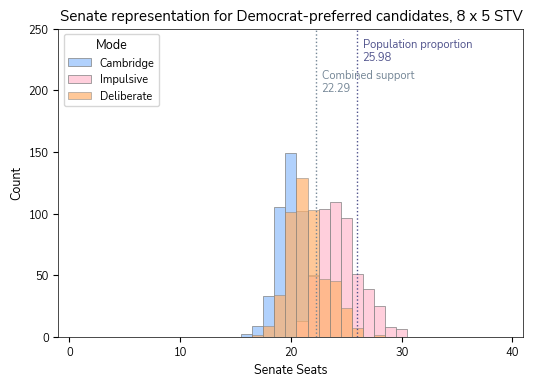

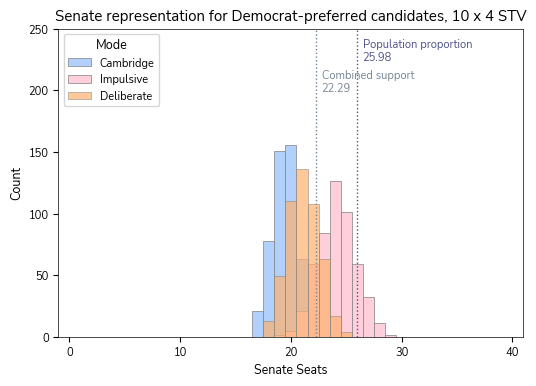

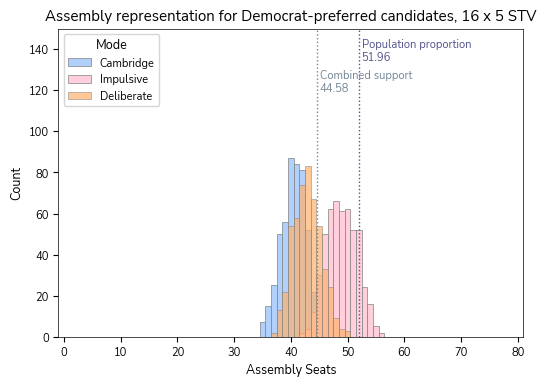

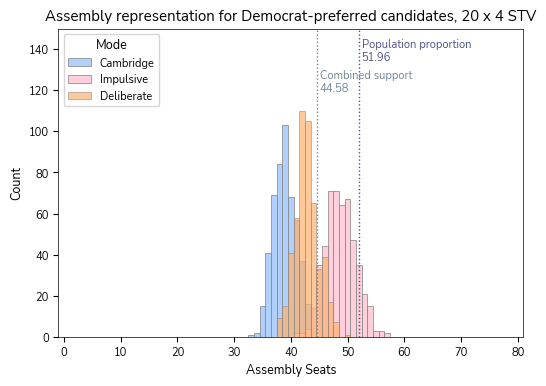

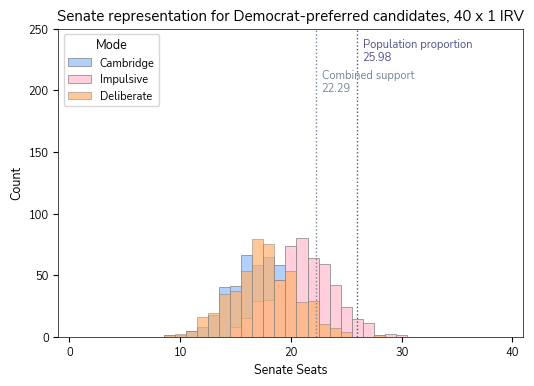

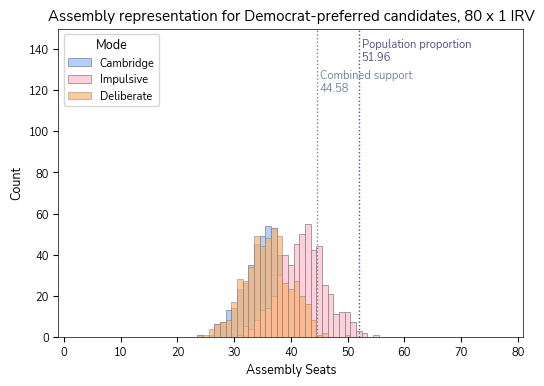

In [158]:
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['font.sans-serif'] = ['Nunito Sans']

agg = (df_part.groupby(["plan", "total_district_num", "mode", "rep"], as_index=False)
      .agg({"D_seats": "sum"}))

dist_seats = {8:5, 10:4, 16:5, 20:4, 40:1, 80:1}

# Define colors for each mode
mode_colors = {
    "cambridge": "xkcd:powder blue",
    "slate_bt": "xkcd:pale pink",
    "slate_pl": "xkcd:apricot"
}
# Define the mapping for the new legend labels
legend_mapping = {
    "slate_bt": "Impulsive",
    "slate_pl": "Deliberate",
    "cambridge": "Cambridge"
}

for dn, group_dn in agg.groupby("total_district_num"): 
    plt.rc('font', size=9)   
    fig, ax = plt.subplots(figsize=(6,4))  # create a figure + axes

    # Plot histogram for each mode
    for mode, group_mode in group_dn.groupby("mode"):
        alpha_val = 0.7 if mode_colors.get(mode) == "xkcd:apricot" else 1.0
        ax.hist(
            group_mode["D_seats"],
            bins=range(group_mode["D_seats"].min(), group_mode["D_seats"].max() + 2),
            align='left',
            edgecolor='gray',
            linewidth=0.5,
            color=mode_colors.get(mode, "xkcd:light gray"),
            alpha=alpha_val,
            label=mode  # add label for legend
        )

    # Reduce the weight of the spines (plot boundary)
    for spine in ax.spines.values():
        spine.set_linewidth(0.5)

    sen_assem = "Senate" if dn*dist_seats[dn] == 40 else "Assembly"
    election = "IRV" if dist_seats[dn]==1 else "STV"
    ylim = 250 if sen_assem == "Senate" else 150

    # set x-axis limits on the Axes
    ax.set_xlim(-1, dn * dist_seats[dn] + 1)
    ax.set_ylim(0, ylim)
    ax.set_xticks(range(0, dn * dist_seats[dn] + 1, 10))
    ax.set_xlabel(f"{sen_assem} Seats")
    ax.set_ylabel("Count")
    ax.set_title(f"{sen_assem} representation for Democrat-preferred candidates, {dn} x {dist_seats[dn]} {election}")
    ax.tick_params(axis='both', which='major', labelsize=8)


    # ADD A MODIFIED LEGEND
    # Get handles and labels from the current axes
    handles, labels = ax.get_legend_handles_labels()

    # Filter out vertical line handles and labels from the main histogram legend
    # and map the labels to the new, descriptive names
    new_labels = []
    new_handles = []
    
    for handle, label in zip(handles, labels):
        # Only process labels that are keys in the legend_mapping (i.e., histogram labels)
        if label in legend_mapping:
            new_labels.append(legend_mapping[label])
            new_handles.append(handle)

    # Add legend for modes using the new labels
    ax.legend(new_handles, new_labels, title="Mode", fontsize=8)



    ### ADD VERTICAL LINES
    color_cs = 'xkcd:steel'
    color_dprop = 'xkcd:twilight'

    ## Add vertical line for combined support
    cs_share = cs*dn*dist_seats[dn]
    ax.axvline(
        cs_share, color=color_cs, linestyle=':', linewidth=1,
        label=f"{share}"
    )

    rounded_cs = f"{cs_share:.2f}"
    cs_text_label = f"Combined support\n{rounded_cs}"
    ax.text(
        cs_share + 0.5, # X-position: slightly to the right of the line
        ylim * 0.83, # Y-position: 95% of the way up the plot
        cs_text_label,
        verticalalignment='center',
        horizontalalignment='left',
        fontsize=8,
        color=color_cs
    )
    
    ## Add vertical line for population proprotionate share
    # Add dotted vertical line at hprop * seats
    share = dprop*dn*dist_seats[dn]
    ax.axvline(
        share, color=color_dprop, linestyle=':', linewidth=1,
        label=f"{share}"
    )
    
    rounded_share = f"{share:.2f}"
    text_label = f"Population proportion \n{rounded_share}"

    ax.text(
        share + 0.5, # X-position: slightly to the right of the line
        ylim * 0.93, # Y-position: 95% of the way up the plot
        text_label,
        verticalalignment='center',
        horizontalalignment='left',
        fontsize=8,
        color=color_dprop
    )

    # Save figure
    plt.show()#savefig(f"figures/hispanic_seats_{dn}x{dist_seats[dn]}_bymode_turn_h0.4_pih0.75_pio0.8_ahh0.25_aho0.75_aoh0.6_aoo0.5.png.png", dpi=300, bbox_inches='tight')

### Install Nunito Font

In [ ]:
import urllib.request
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import os


url = "https://raw.githubusercontent.com/googlefonts/NunitoSans/main/fonts/ttf/NunitoSans-Regular.ttf"
font_path = "NunitoSans-Regular.ttf"
font_family = 'Nunito Sans' # Matplotlib needs the exact font name

try:
    print(f"Downloading font from: {url}")
    urllib.request.urlretrieve(url, font_path)
    print("Download complete.")

    file_size = os.path.getsize(font_path)
    print("Font file size (bytes):", file_size)
    
    # Register in Matplotlib
    fm.fontManager.addfont(font_path)
    plt.rcParams['font.family'] = font_family

    # Quick test plot
    plt.figure()
    plt.title(f"Plot with {font_family}", fontsize=16)
    plt.xlabel("X axis label")
    plt.ylabel("Y axis label")
    plt.plot([1, 2, 3], [4, 1, 3])
    plt.grid(True)
    plt.show()
    
except Exception as e:
    print(f"An error occurred: {e}")
    print("Check the URL again or ensure Matplotlib is correctly installed with FreeType support.")
